## Nelson-Siegel (NS) & Nelson-Siegel-Svensson (NSS) Parameterisation

**Term structure modelling** is a central problem in interest rate markets, particularly for pricing, risk management, and macro-financial analysis.

Given a cross-section of swap rates across maturities, the objective of this Jupyter notebook is to construct a smooth and economically interpretable yield curve, which will then be used as a benchmark for **variational autoencoders**. We are going to use OIS data for GBP, EUR and USD, from 30/01/2023 to 21/01/2026.

### Nelson-Siegel Model

The Nelson-Siegel and Nelson-Siegel-Svensson models are two typical examples of using parametric models to build yield curves. Their advantages include:
- Only have a few parameters, which makes the computation easy and stable;
- Each parameter has an economic meaning, which makes it economically interpretable.

However, their drawbacks are also clear:
- may fail to capture complex term structures;
- not derived from no-arbitrage principles, leading to a lack of dynamic consistency.

In general, they have been proven to work well in many cases, and are widely used by banks, especially central banks. Therefore, it is still reasonable to use them as benchmarks for VAE.

The Nelson-Siegel model represents the instantaneous forward rate curve $f(\tau)$ where $\tau$ is the time to maturity as a combination of three components:
$$
f(\tau) = \beta_1 + \beta_2 e^{-\tau/\lambda} + \beta_3 \frac{\tau}{\lambda} e^{-\tau/\lambda}
$$
and after averaging to describe zero rates (yields) curve, we have
\begin{align}
y(\tau) &= \frac{1}{\tau}\int^\tau_0f(u)du\\
&= \beta_1 + \beta_2 \left(\frac{1 - e^{-\tau/\lambda}}{\tau/\lambda}\right) + \beta_3\left(\frac{1-e^{-\tau/\lambda}}{\tau/\lambda} - e^{-\tau/\lambda}\right)\\
\end{align}

where
- $\beta_1$: parallel shift; economically, long-run interest rate;
- $\beta_2$: slope (short-term effect); economically, difference between short and long rates;
- $\beta_3$: curvature of the instantaneous forward curve (medium-term hump); economically, captures medium-term deviations
- $\lambda$: parameter controlling the decay rate.

### Nelson-Siegel-Svensson Model

Historically, the yield curve sometimes exhibit a second hump. This is where the NSS extension helps to capture it. Specifically, we need one more term and two more parameters $\beta_4$ and $\kappa$:

$$
y(\tau) = \beta_1 + \beta_2 \left(\frac{1 - e^{-\tau/\lambda}}{\tau/\lambda}\right) + \beta_3\left(\frac{1-e^{-\tau/\lambda}}{\tau/\lambda} - e^{-\tau/\lambda}\right) + \beta_4 \left(\frac{1 - e^{-\tau/\kappa}}{\tau/\lambda} - e^{-\tau/\kappa}\right)
$$
where $\lambda \neq \kappa$.

### Implementation

The NS and NSS models are calibrated to daily swap rate data for USD, GBP, and EUR. The dataset consists of observed swap rates at maturities of 2, 3, 5, 10, 15, 20, and 30 years. For each trading day, the cross-sectional term structure is fitted independently.

For each day $t$, the model parameters are estimated by minimising the sum of squared errors between model-implied yields and observed market swap rates
$$
\min_{\mathbf{\theta}} \sum^7_{i = 1} \left(y(\tau_i;\mathbf{\theta}) - y_i^{\text{market}}\right)^2
$$
where $\tau_i$ represents time to maturity, $y_i^{\text{market}}$ is the observed swap rate corrresponding to $\tau_i$, and

$$
\theta =
\begin{cases}
(\beta_1, \beta_2, \beta_3, \lambda), & \text{NS model}, \\
(\beta_1, \beta_2, \beta_3, \beta_4, \lambda, \kappa), & \text{NSS model}.
\end{cases}
$$
is the parameter vector.

The optimisation is performed using the *least_squares* package from the *scipy.optimize* library.

Appropriate initial values are crucial for convergence due to the non-convex nature of the optimisation problem. The initial level parameter is set equal to the long-maturity rate, while the slope parameter is initialised as the difference between short- and long-term rates. Curvature parameters are initialised near zero. For the NSS model, multiple initial starting points are used, and the best solution (in terms of root mean squared error) is selected.

To assess the quality of the fit, model-implied yield curves are plotted against observed market rates. For each selected date, the fitted curve is evaluated on a dense maturity grid to obtain a smooth representation. In addition, comparative plots are constructed by placing USD, GBP, and EUR yield curves side by side for the same date. This allows for a direct visual comparison of cross-currency term structure differences. The vertical axis is fixed across plots to ensure consistency and facilitate comparison.

In [1]:
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import CubicSpline

# Extract data from the datasheet

FILE_PATH = "Bloomberg - Historical Data v2026-01-21.xlsx"
table_mapping = {"gbp ois results":[] ,
    "eur estr results":[],
    "usd sofr results":[]
}
ticker_mapping = {"gbp ois results":['BPSWS',' Curncy'] ,
    "eur estr results":['EESWE',' Curncy'],
    "usd sofr results":['USOSFR',' Curncy']
}

for item in ticker_mapping:
    for i in ['2', '3', '5', '10', '15', '20', '30']:
        table_mapping[item].append(ticker_mapping[item][0]+i+ticker_mapping[item][1])
print(table_mapping)

{'gbp ois results': ['BPSWS2 Curncy', 'BPSWS3 Curncy', 'BPSWS5 Curncy', 'BPSWS10 Curncy', 'BPSWS15 Curncy', 'BPSWS20 Curncy', 'BPSWS30 Curncy'], 'eur estr results': ['EESWE2 Curncy', 'EESWE3 Curncy', 'EESWE5 Curncy', 'EESWE10 Curncy', 'EESWE15 Curncy', 'EESWE20 Curncy', 'EESWE30 Curncy'], 'usd sofr results': ['USOSFR2 Curncy', 'USOSFR3 Curncy', 'USOSFR5 Curncy', 'USOSFR10 Curncy', 'USOSFR15 Curncy', 'USOSFR20 Curncy', 'USOSFR30 Curncy']}


In [2]:
# Reconstruct the datasheet for further analysis
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")
TARGET_TENORS = ['2Y', '3Y', '5Y', '10Y', '15Y', '20Y', '30Y']
def find_ticker_col(raw_df, ticker):
    for col in range(raw_df.shape[1]):
        cell = str(raw_df.iloc[0, col]).strip()
        if ticker.lower() in cell.lower():
            return col
    return None

In [3]:
# Collect data
def get_data(SHEET_NAME):
    raw = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME, header=None)
    ticker_col_map = {}
    for ticker, tenor in zip(table_mapping[SHEET_NAME], TARGET_TENORS):
        col_idx = find_ticker_col(raw, ticker)

        ticker_col_map[tenor] = {
            "ticker": ticker,
            "date_col": col_idx - 1,
            "rate_col": col_idx
        }


    result_df = None

    for tenor, info in ticker_col_map.items():
        date_series = raw.iloc[1:, info["date_col"]]
        rate_series = raw.iloc[1:, info["rate_col"]]

        temp_df = pd.DataFrame({
            "Date": pd.to_datetime(date_series.values, errors="coerce", format="mixed"),
            tenor: pd.to_numeric(rate_series.values, errors="coerce")
        }).dropna(subset=["Date"])

        if result_df is None:
            result_df = temp_df
        else:
            result_df = pd.merge(result_df, temp_df, on="Date", how="outer")

    result_df = result_df.sort_values("Date")
    start_date = pd.Timestamp("2023-01-30")
    result_df = result_df.dropna(subset=TARGET_TENORS)
    result_df = result_df[result_df["Date"] >= start_date]
    result_df = result_df.reset_index(drop=True)
    return result_df

In [4]:
result_usd = get_data("usd sofr results")
result_gbp = get_data("gbp ois results")
result_eur = get_data("eur estr results")

In [5]:
result_gbp.head()

,Date,2Y,3Y,5Y,10Y,15Y,20Y,30Y
0,2023-01-30,4.07450,3.8584,3.6176,3.38150,3.3405,3.29450,3.1835
1,2023-01-31,4.04160,3.8280,3.6038,3.37950,3.3475,3.30787,3.2023
2,2023-02-01,4.00578,3.7894,3.5732,3.36200,3.3370,3.28710,3.1881
3,2023-02-02,3.78910,3.5322,3.2669,3.07695,3.0760,3.06200,2.9800
4,2023-02-03,3.81490,3.5735,3.3288,3.14340,3.1451,3.13010,3.0516


In [6]:
from scipy.optimize import least_squares

maturity_columns = ["2Y", "3Y", "5Y", "10Y", "15Y", "20Y", "30Y"]
maturities = np.array([2, 3, 5, 10, 15, 20, 30], dtype=float)

# Define NS model
def ns_yield(tau, beta0, beta1, beta2, lamb):
    tau = np.asarray(tau, dtype=float)
    x = tau / lamb
    term1 = (1.0 - np.exp(-x)) / x
    term2 = term1 - np.exp(-x)
    return beta0 + beta1 * term1 + beta2 * term2

# Define NSS model
def nss_yield(tau, beta0, beta1, beta2, beta3, lamb1, lamb2):
    tau = np.asarray(tau, dtype=float)

    x1 = tau / lamb1
    term1 = (1.0 - np.exp(-x1)) / x1
    term2 = term1 - np.exp(-x1)

    x2 = tau / lamb2
    term3 = (1.0 - np.exp(-x2)) / x2 - np.exp(-x2)

    return beta0 + beta1 * term1 + beta2 * term2 + beta3 * term3

# Define NS and NSS residuals, for optimisation purpose
def ns_residuals(params, tau, y_obs):
    beta0, beta1, beta2, lamb = params
    y_fit = ns_yield(tau, beta0, beta1, beta2, lamb)
    return y_fit - y_obs

def nss_residuals(params, tau, y_obs):
    beta0, beta1, beta2, beta3, lamb1, lamb2 = params
    y_fit = nss_yield(tau, beta0, beta1, beta2, beta3, lamb1, lamb2)
    return y_fit - y_obs

In [7]:
# Fit the NS model, by using data of 1 day.
def fit_ns_single_day(tau, y_obs):
    tau = np.asarray(tau, dtype=float)
    y_obs = np.asarray(y_obs, dtype=float)

    beta0_init = y_obs[-1]
    beta1_init = y_obs[0] - y_obs[-1]
    beta2_init = 0.0
    lamb_init = 2.0

    x0 = np.array([beta0_init, beta1_init, beta2_init, lamb_init], dtype=float)

    lower_bounds = [-20.0, -20.0, -20.0, 0.05]
    upper_bounds = [ 20.0,  20.0,  20.0, 30.0]

    result = least_squares(
        ns_residuals,
        x0=x0,
        bounds=(lower_bounds, upper_bounds),
        args=(tau, y_obs),
        method="trf"
    )

    beta0, beta1, beta2, lamb = result.x
    y_fit = ns_yield(tau, beta0, beta1, beta2, lamb)
    rmse = np.sqrt(np.mean((y_fit - y_obs) ** 2))

    return {
        "beta0": beta0,
        "beta1": beta1,
        "beta2": beta2,
        "lambda": lamb,
        "rmse": rmse,
        "success": result.success,
        "cost": result.cost,
        "nfev": result.nfev,
        "y_fit": y_fit
    }

In [8]:
# Fit the NSS model, by using data of 1 day.
def fit_nss_single_day(tau, y_obs):
    tau = np.asarray(tau, dtype=float)
    y_obs = np.asarray(y_obs, dtype=float)

    beta0_init = y_obs[-1]
    beta1_init = y_obs[0] - y_obs[-1]

    candidate_starts = [
        [beta0_init, beta1_init, 0.0, 0.0, 1.0, 5.0],
        [beta0_init, beta1_init, 0.5, -0.5, 1.5, 7.0],
        [beta0_init, beta1_init, -0.5, 0.5, 2.0, 10.0],
        [beta0_init, beta1_init, 1.0, -1.0, 0.8, 8.0],
    ]

    lower_bounds = [-20.0, -20.0, -20.0, -20.0, 0.05, 0.05]
    upper_bounds = [ 20.0,  20.0,  20.0,  20.0, 30.0, 30.0]

    best_result = None
    best_rmse = np.inf

    for x0 in candidate_starts:
        try:
            result = least_squares(
                nss_residuals,
                x0=np.array(x0, dtype=float),
                bounds=(lower_bounds, upper_bounds),
                args=(tau, y_obs),
                method="trf",
                max_nfev=5000
            )

            beta0, beta1, beta2, beta3, lamb1, lamb2 = result.x
            y_fit = nss_yield(tau, beta0, beta1, beta2, beta3, lamb1, lamb2)
            rmse = np.sqrt(np.mean((y_fit - y_obs) ** 2))

            if rmse < best_rmse:
                best_rmse = rmse
                best_result = {
                    "beta0": beta0,
                    "beta1": beta1,
                    "beta2": beta2,
                    "beta3": beta3,
                    "lambda1": lamb1,
                    "lambda2": lamb2,
                    "rmse": rmse,
                    "success": result.success,
                    "cost": result.cost,
                    "nfev": result.nfev,
                    "y_fit": y_fit
                }
        except Exception:
            continue

    return best_result

In [9]:
def fit_curve_dataframe(df, model="NS", date_col="Date", maturity_cols=None, tau=None):
    if maturity_cols is None:
        maturity_cols = ["2Y", "3Y", "5Y", "10Y", "15Y", "20Y", "30Y"]
    if tau is None:
        tau = np.array([2, 3, 5, 10, 15, 20, 30], dtype=float)

    output_rows = []

    for idx, row in df.iterrows():
        date_value = row[date_col]
        y_obs = row[maturity_cols].astype(float).values

        valid_mask = np.isfinite(y_obs)
        tau_valid = tau[valid_mask]
        y_valid = y_obs[valid_mask]

        try:
            if model.upper() == "NS":
                fit_result = fit_ns_single_day(tau_valid, y_valid)
                output_rows.append({
                    "Date": date_value,
                    "beta0": fit_result["beta0"],
                    "beta1": fit_result["beta1"],
                    "beta2": fit_result["beta2"],
                    "lambda": fit_result["lambda"],
                    "rmse": fit_result["rmse"],
                    "success": fit_result["success"]
                })

            elif model.upper() == "NSS":
                fit_result = fit_nss_single_day(tau_valid, y_valid)

                if fit_result is None:
                    output_rows.append({
                        "Date": date_value,
                        "success": False,
                        "error": "NSS fit failed"
                    })
                else:
                    output_rows.append({
                        "Date": date_value,
                        "beta0": fit_result["beta0"],
                        "beta1": fit_result["beta1"],
                        "beta2": fit_result["beta2"],
                        "beta3": fit_result["beta3"],
                        "lambda1": fit_result["lambda1"],
                        "lambda2": fit_result["lambda2"],
                        "rmse": fit_result["rmse"],
                        "success": fit_result["success"]
                    })

        except Exception as e:
            output_rows.append({
                "Date": date_value,
                "success": False,
                "error": str(e)
            })

    return pd.DataFrame(output_rows)

In [10]:
# Fit NS Model
ns_usd = fit_curve_dataframe(
    result_usd,
    model="NS",
    date_col="Date",
    maturity_cols=maturity_columns,
    tau=maturities
)

ns_gbp = fit_curve_dataframe(
    result_gbp,
    model="NS",
    date_col="Date",
    maturity_cols=maturity_columns,
    tau=maturities
)

ns_eur = fit_curve_dataframe(
    result_eur,
    model="NS",
    date_col="Date",
    maturity_cols=maturity_columns,
    tau=maturities
)

In [11]:
# Fit NSS Model
nss_usd = fit_curve_dataframe(
    result_usd,
    model="NSS",
    date_col="Date",
    maturity_cols=maturity_columns,
    tau=maturities
)

nss_gbp = fit_curve_dataframe(
    result_gbp,
    model="NSS",
    date_col="Date",
    maturity_cols=maturity_columns,
    tau=maturities
)

nss_eur = fit_curve_dataframe(
    result_eur,
    model="NSS",
    date_col="Date",
    maturity_cols=maturity_columns,
    tau=maturities
)

In [12]:
ns_gbp.head()

,Date,beta0,beta1,beta2,lambda,rmse,success
0,2023-01-30,3.145257,1.725416,0.000140,1.421568,0.023109,True
1,2023-01-31,3.169802,1.695630,-0.000111,1.308374,0.022493,True
2,2023-02-01,3.161328,1.697033,-0.000002,1.235041,0.023190,True
3,2023-02-02,2.970726,2.034085,-1.291137,1.663650,0.020164,True
4,2023-02-03,3.041719,1.898040,-1.172613,1.663434,0.019642,True


In [13]:
nss_gbp.head()

,Date,beta0,beta1,beta2,beta3,lambda1,lambda2,rmse,success
0,2023-01-30,1.820618,2.929103,3.400686e-05,3.817291,2.448130,13.917394,0.005282,True
1,2023-01-31,1.831672,2.863563,3.391111e-06,3.858393,2.444081,14.049116,0.006721,True
2,2023-02-01,2.148121,2.561896,2.246061e-05,2.962925,2.085638,13.000056,0.008141,True
3,2023-02-02,1.587574,3.118750,3.001952e-08,4.030875,1.932764,14.352784,0.004059,True
4,2023-02-03,1.681276,2.969722,1.021270e-05,3.960354,2.007800,14.440602,0.005268,True


In [14]:
# Single graph
def plot_fit_for_one_day(df_rates, df_params, model="NS", row_index=0,
                         date_col="Date", maturity_cols=None, tau=None):
    if maturity_cols is None:
        maturity_cols = ["2Y", "3Y", "5Y", "10Y", "15Y", "20Y", "30Y"]
    if tau is None:
        tau = np.array([2, 3, 5, 10, 15, 20, 30], dtype=float)

    row_rates = df_rates.iloc[row_index]
    row_params = df_params.iloc[row_index]

    y_obs = row_rates[maturity_cols].astype(float).values
    date_value = row_rates[date_col]

    tau_grid = np.linspace(0.25, 30, 300)

    if model.upper() == "NS":
        y_grid = ns_yield(
            tau_grid,
            row_params["beta0"],
            row_params["beta1"],
            row_params["beta2"],
            row_params["lambda"]
        )
    elif model.upper() == "NSS":
        y_grid = nss_yield(
            tau_grid,
            row_params["beta0"],
            row_params["beta1"],
            row_params["beta2"],
            row_params["beta3"],
            row_params["lambda1"],
            row_params["lambda2"]
        )
    else:
        raise ValueError("model must be either 'NS' or 'NSS'")

    plt.figure(figsize=(8, 5))
    plt.plot(tau, y_obs, "o", label="Market swap rates")
    plt.plot(tau_grid, y_grid, "-", label=f"{model} fitted curve")
    plt.xlabel("Maturity (years)")
    plt.ylabel("Swap rate")
    plt.ylim(3.0, 5.0)
    plt.xlim(0,31)
    plt.title(f"{model} fit on {date_value}")
    plt.legend()
    plt.grid(True)
    plt.show()

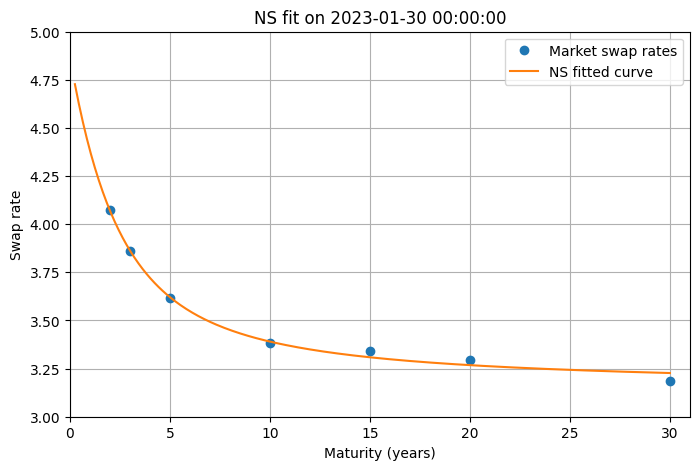

In [15]:
plot_fit_for_one_day(result_gbp, ns_gbp, model="NS", row_index=0)

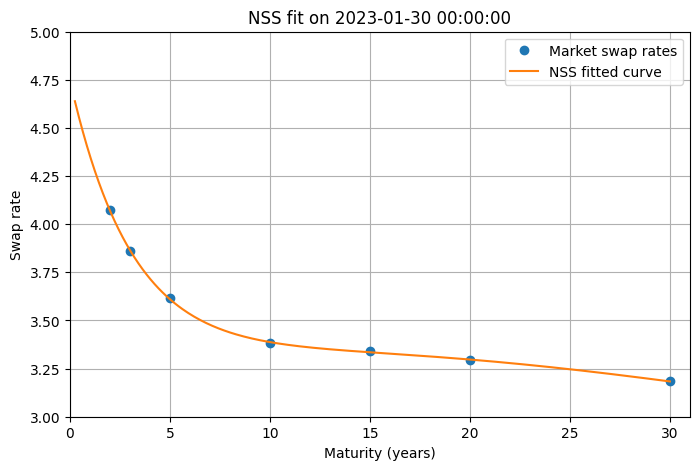

In [16]:
plot_fit_for_one_day(result_gbp, nss_gbp, model="NSS", row_index=0)

In [17]:
# Three curves in a row.
import os
os.makedirs("fig", exist_ok=True)

def plot_three_currencies(
    df_usd, df_gbp, df_eur,
    params_usd, params_gbp, params_eur,
    model="NS",
    row_index=0,
    date_col="Date",
    maturity_cols=None,
    tau=None
):
    if maturity_cols is None:
        maturity_cols = ["2Y", "3Y", "5Y", "10Y", "15Y", "20Y", "30Y"]
    if tau is None:
        tau = np.array([2, 3, 5, 10, 15, 20, 30], dtype=float)

    tau_grid = np.linspace(0.25, 30, 300)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    datasets = [
        ("USD", df_usd, params_usd),
        ("GBP", df_gbp, params_gbp),
        ("EUR", df_eur, params_eur),
    ]

    for ax, (label, df_rates, df_params) in zip(axes, datasets):

        row_rates = df_rates.iloc[row_index]
        row_params = df_params.iloc[row_index]

        y_obs = row_rates[maturity_cols].astype(float).values
        date_value = row_rates[date_col]

        if model.upper() == "NS":
            y_grid = ns_yield(
                tau_grid,
                row_params["beta0"],
                row_params["beta1"],
                row_params["beta2"],
                row_params["lambda"]
            )
        else:
            y_grid = nss_yield(
                tau_grid,
                row_params["beta0"],
                row_params["beta1"],
                row_params["beta2"],
                row_params["beta3"],
                row_params["lambda1"],
                row_params["lambda2"]
            )

        ax.plot(tau, y_obs, "o", label="Market")
        ax.plot(tau_grid, y_grid, "-", label="Fit")

        ax.set_title(f"{label} ({date_value})")
        ax.set_xlabel("Maturity (years)")

        ax.set_ylim(2.2, 5.0)
        ax.set_xlim(0,31)

        ax.grid(True)

    axes[0].set_ylabel("Swap rate")
    axes[0].legend()

    plt.tight_layout()
    date_value = df_usd.iloc[row_index][date_col]
    date_str = date_value.strftime('%Y-%m-%d')
    model_str = model.lower()

    filename = f"fig/{model_str}_usd_gbp_eur_{date_str}.png"

    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

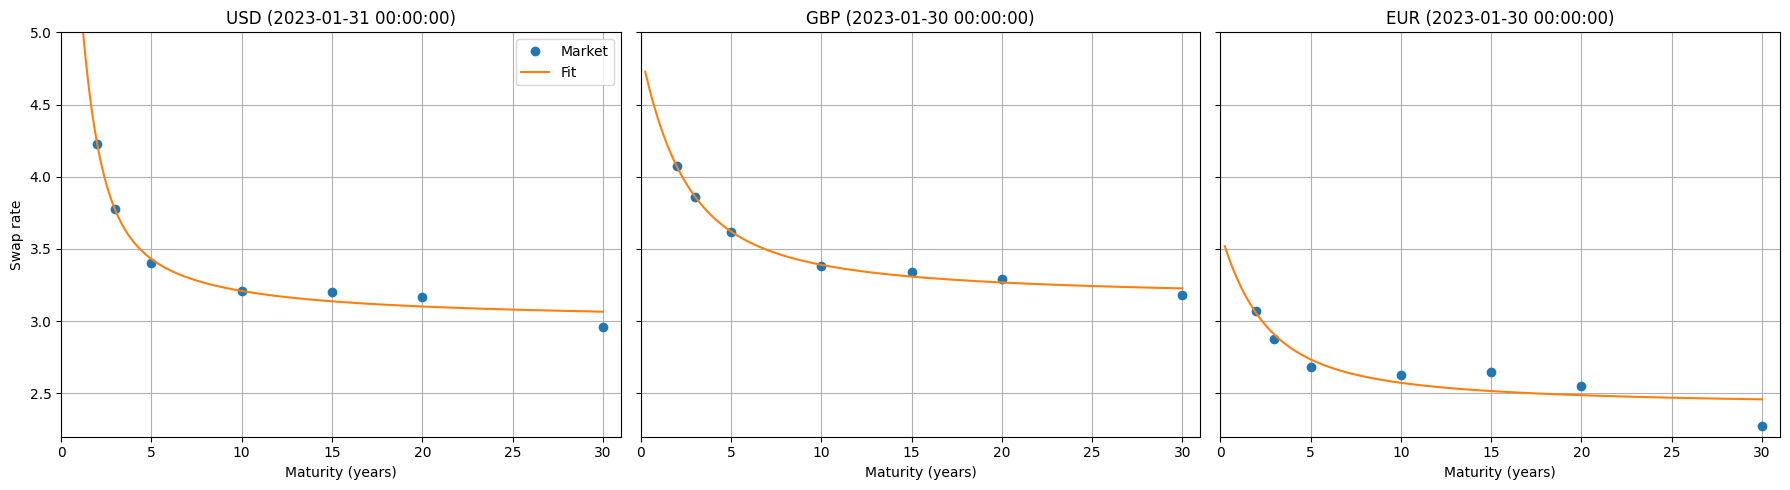

In [18]:
plot_three_currencies(
    result_usd, result_gbp, result_eur,
    ns_usd, ns_gbp, ns_eur,
    model="NS",
    row_index=0
)

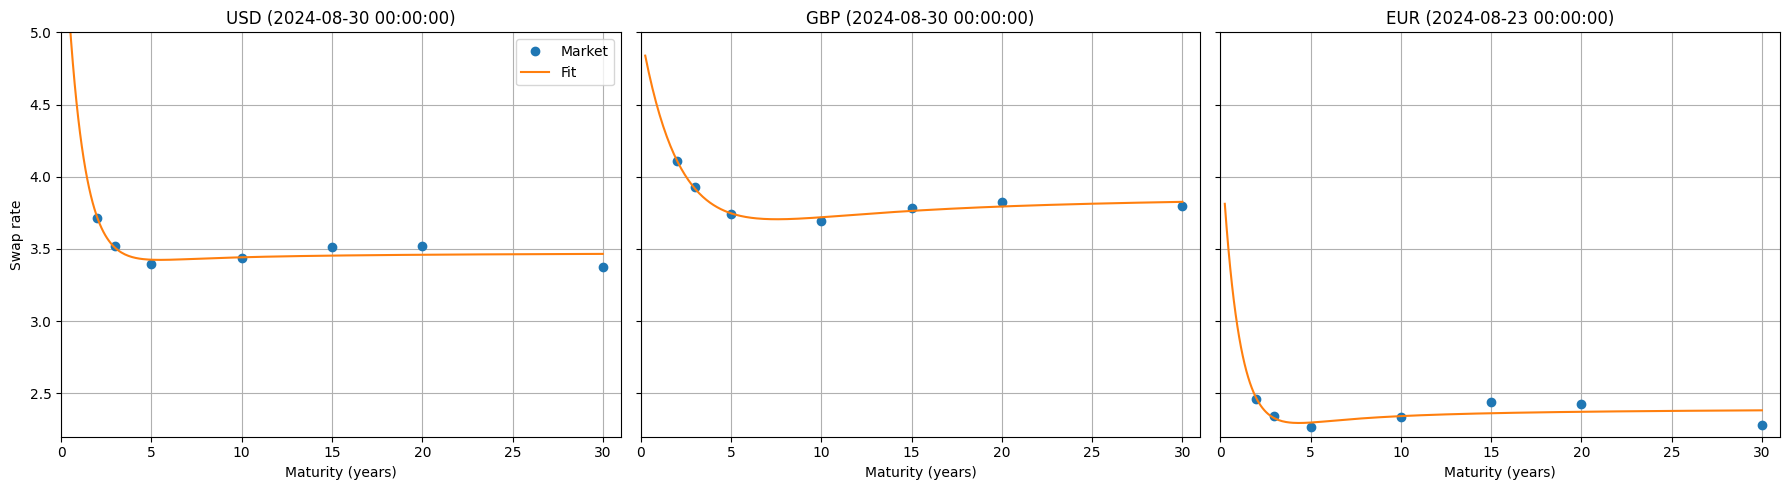

In [19]:
plot_three_currencies(
    result_usd, result_gbp, result_eur,
    ns_usd, ns_gbp, ns_eur,
    model="NS",
    row_index=400
)

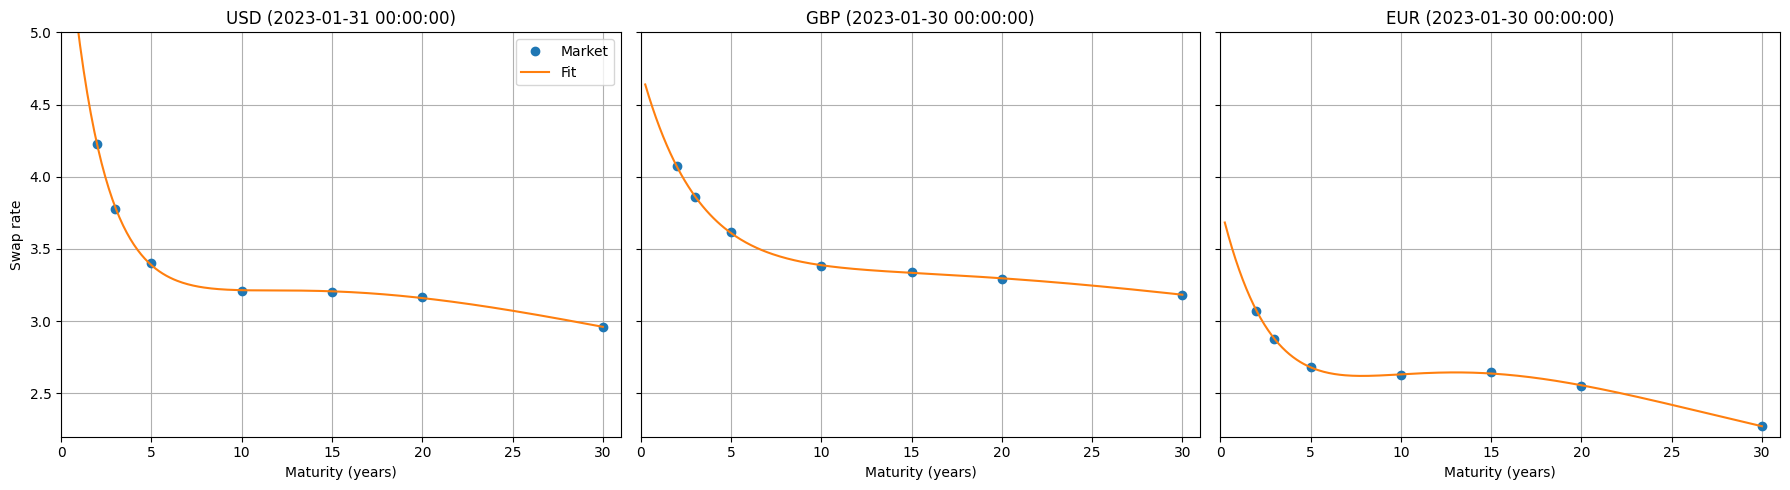

In [20]:
plot_three_currencies(
    result_usd, result_gbp, result_eur,
    nss_usd, nss_gbp, nss_eur,
    model="NSS",
    row_index=0
)

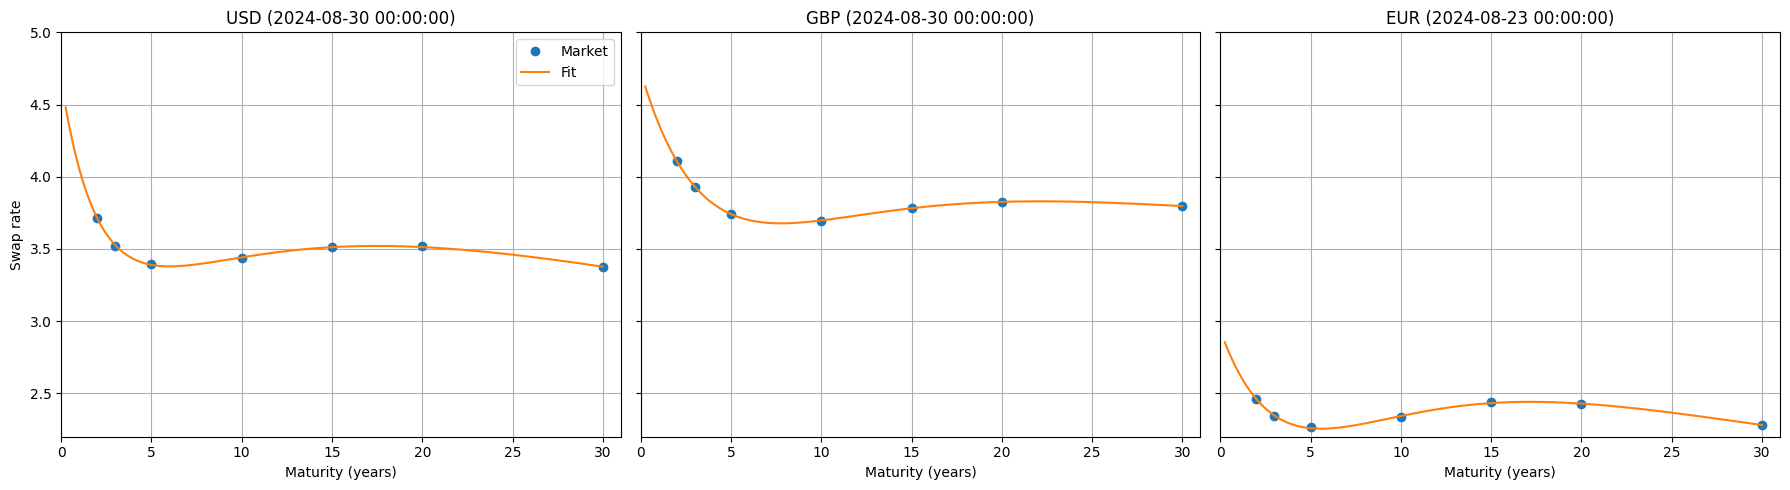

In [21]:
plot_three_currencies(
    result_usd, result_gbp, result_eur,
    nss_usd, nss_gbp, nss_eur,
    model="NSS",
    row_index=400
)

In [22]:
print("GBP NS average RMSE:", ns_gbp["rmse"].mean())
print("GBP NSS average RMSE:", nss_gbp["rmse"].mean())

print("USD NS average RMSE:", ns_usd["rmse"].mean())
print("USD NSS average RMSE:", nss_usd["rmse"].mean())

print("EUR NS average RMSE:", ns_eur["rmse"].mean())
print("EUR NSS average RMSE:", nss_eur["rmse"].mean())

GBP NS average RMSE: 0.02306923400530034
GBP NSS average RMSE: 0.0031216719219463278
USD NS average RMSE: 0.05331719827517675
USD NSS average RMSE: 0.004799517332256643
EUR NS average RMSE: 0.05461727162387494
EUR NSS average RMSE: 0.005918507991452626


The results indicate a clear trade-off between model simplicity and fitting accuracy. Across all three currencies, the NSS model achieves substantially lower average RMSE compared to the NS model.

From the plots, the NS model captures the general level and slope of the yield curve but fails to reproduce more complex features such as slight humps in the medium-to-long end. In contrast, the additional flexibility of NSS allows it to better accommodate these features, resulting in a closer match to the observed swap rates.

However, this increased flexibility comes at the cost of longer computation time and potential overfitting. The algorithm takes around 5.8 seconds to compute all parameters for NS model, whereas almost 203 seconds are required to compute those for NSS. Moreover, given that only a limited number of maturities are available each day, the NSS model may fit noise in the data rather than purely structural features of the yield curve. required to compute those for NSS. Therefore, the NS model remains more parsimonious and robust, which possibly makes it a better choice.